# Árbol KD — Sistema de Logística de Entregas

---

## Problema

Eres parte de un equipo que desarrolla un **sistema de logística de entregas** en una ciudad.  
Tienes coordenadas $(x, y)$ de **10.000 puntos de entrega** (datos estáticos, no cambian).

Necesitas implementar un sistema que responda eficientemente:

1. **Búsqueda por radio:** ¿Qué puntos de entrega están a un radio de **500 metros** de un punto dado? *(tener en cuenta las unidades)*
2. **Vecino más cercano:** ¿Cuál es el punto de entrega más cercano a una ubicación dada?

---

## Objetivo

Implementar un **Árbol KD desde cero** y compararlo con **búsqueda por fuerza bruta** (listas, sin estructuras auxiliares).

---

## Micro-tareas

1. **Construir el Árbol KD** — no se pueden usar librerías como `scipy.spatial.KDTree`
2. **Búsqueda por radio (Range Search)** — retornar todos los puntos $p$ tales que:
$$\|p - q\|_2 = \sqrt{(p_x - q_x)^2 + (p_y - q_y)^2} \leq r$$
3. **Vecinos más cercanos** — puntos dentro del radio y el más cercano
4. **Verificación visual** — radio y puntos encontrados dentro del radio
5. **Verificación visual** — vecino más cercano

---

## Análisis Comparativo

> ¿Para qué tamaño de datos el Árbol KD comienza a ser más rápido que la **fuerza bruta** (listas)?

| Método | Construcción | Range Search | Vecino más cercano |
|---|---|---|---|
| Fuerza Bruta | $O(1)$ | $O(n)$ | $O(n)$ |
| Árbol KD | $O(n \log n)$ | $O(\sqrt{n} + k)$ | $O(\log n)$ |

---

## Notas

-  **Recomendado:** implementar para $k$ dimensiones, mínimo $2D$
-  **No permitido:** soluciones completas de internet o *vibe coding*
-  **Sí permitido:** apoyarse en IA o internet como referencia
-  Se pueden hacer preguntas

---

## Forma de Entrega

Repositorio **GitHub** con la siguiente estructura:

```
mi-repo-kdtree/
├── README.md      # Descripción y cómo ejecutar
├── KDtree.py      # Implementación del Árbol KD
├── test.py        # Pruebas unitarias + visualizaciones
└── analisis.py    # Métricas de rendimiento y discusión
```



# ¿Qué es un Árbol KD?

Un **árbol KD** es una estructura de datos geométrica, variante avanzada de los árboles ABB. Mientras un árbol ABB normal sirve para organizar datos en **una sola dimensión**, el árbol KD está diseñado para organizar datos en **K dimensiones** como un mapa 2D con $x$ e $y$, o un espacio 3D con $x$, $y$ y $z$.

---

Funciona como un **archivador geográfico**. En vez de tener los 10.000 puntos amontonados en una lista desordenada, el árbol KD organiza el espacio dividiéndolo repetidamente en secciones cada vez más pequeñas, trazando líneas que parten el mapa por la mitad.

---

## ¿Cómo funciona? — Divide y Vencerás

El árbol aplica el principio de **divide y vencerás** de forma recursiva:

1.  Toma todo el mapa y traza una **línea vertical** por el punto central → divide en *"Izquierda"* y *"Derecha"*
2.  A cada mitad le traza una **línea horizontal** → divide en *"Arriba"* y *"Abajo"*
3.  Este proceso se **repite recursivamente** alternando los ejes hasta aislar cada punto

---

## Su mayor fortaleza — El descarte masivo

Cuando buscas puntos dentro de un radio específico, el árbol evalúa sus divisiones y si **toda una rama está del otro lado de una línea divisoria lejana**, la descarta completa sin revisar cada punto individualmente.

---

## Aplicado a nuestro problema de Logística

Con 10.000 puntos de entrega, el árbol KD responde eficientemente preguntas como:

- *¿Qué puntos están a 500 metros de aquí?*
- *¿Cuál es el punto de entrega más cercano?*

Aquí es donde el árbol KD **destroza la fuerza bruta**.

---

## Árbol KD vs Fuerza Bruta

### Con fuerza bruta (listas tradicionales)
El sistema calcula la distancia matemática entre la ubicación dada y los **10.000 puntos uno por uno** hasta encontrar el más cercano.

### Con el Árbol KD
El sistema simplemente *"baja"* por las divisiones del mapa hasta la zona correcta. En lugar de 10.000 cálculos, por lo general solo hace aproximadamente **14 cálculos**:

$$\log_2(10.000) \approx 14$$


Esto es una mejora enorme en eficiencia, especialmente a medida que el número de puntos crece. Cuando buscamos puntos dentro de un radio, el árbol KD puede descartar grandes secciones del mapa en cuestión de **milisegundos**.

---

## Su único defecto

La construcción o modificación del árbol es más lenta si los puntos **cambian frecuentemente**.

- Está hecho para datos fijos.
- Insertar o eliminar puntos lo desbalancea.
- Al desbalancearse, las búsquedas dejan de ser rápidas.
- Para arreglarlo, hay que reconstruir el árbol, lo cual es costoso.

En este caso **no es problema** ya que los datos son estáticos, haciendo que el árbol KD sea perfecto y óptimo para este problema de logística de entregas.

# **Contruccion del arbol**

Para la construccion de este arbol usamos una estructura basica de clase NodoKD

Esta es la base inicializa los atributos del nodo, como punto que es la informacion de cada punto y izquierda y derecha que son las conexiones a nodos hijo que inician en None

---


## **El algoritmo de construccion del arbol**

El algoritmo que se realizo toma la lista completa de puntos y arma el arbol de forma recursiva, dividiendo el espacio la funcion se llama a si misma y lo hace en varios pasos

1. Condicion de parada si la listas llega vacia, la funcion se detiene y devuelve None. Esto le indica al arbol que llego al final de una rama y no hay mas divisiones que hacer

2. Elegir eje de corte primero calcula dinamicamente las dimensiones de datos K y luego usa el modulo con la profundidad actual para alternar el eje de corte en cada nivel del arbol. en 2D alterna entre x(0) e y(1)

3. El calculo de la mediana lo hizo sacando la lista de todos los datos ordenados una vez, sacamos una lista de todos los datos ennumerandolas cada dato teniendo un indice en orden correspondiente, sacamos una lista de indices y a esta lista de datos le sacamos la mediana usamos median_low para aproximar la mediana al punto mas cercano y una vez tengamos el indice obtenido por la mediana sacamos el punto medio y empieza desde alli a construir el arbol.

4. Ramificacion construye el nodo asignandole el punto medio y luego envia el resto de puntos a sus hijos dividiendo la lista original en izquierda donde va desde el inicio hasta el punto medio y derecha que es desde el punto medio + 1 hasta el final. esto se hace recursivamente para cada nodo hijo, creando asi la estructura del arbol.


In [12]:
import math
import statistics

class NodoKD:
    #inicializamos los atributos de cada nodo del arbol
    def __init__(self, punto, izquierda=None, derecha=None):
        self.punto = punto
        self.izquierda = izquierda
        self.derecha = derecha

def construccion_arbolKD(puntos, profundidad=0):

#llamada recursiva cuando la rama que estemos parados no tenga mas puntos devuelva None definiendo las hojas del arbol
    if not puntos:
        return None

#definimos que dimension manejaran los datos del arbol
    k = len(puntos[0]["coordenadas"])

#esto es para definir dependiendo la profundidad que eje trabajara ya sea 0 eje x o 1 eje y
    eje = profundidad % k

    #esto es para ordenar todos los datos de menor a mayor segun el eje dandonos las lista de puntos completa
    puntos_ordenados = sorted(puntos, key=lambda p: p["coordenadas"][eje])

   #Creamos una lista ennumerando los puntos estando ordenados en indices
    punto_indice = list(enumerate(puntos_ordenados))

    #Extraemos los indices de todos los puntos ordenados
    indices = [item[0] for item in punto_indice]

    #ese conjunto de indices le calculamos la mediana usamos _low para la aproximacion al punto mas cercano de esa mediana
    indice_mediana = statistics.median_low(indices)

    #ya teniendo el indice que pasa por un punto a partir de la mediana extraemos el punto a partir de ese indice
    punto_mediana = punto_indice[indice_mediana]


    return NodoKD(
        #de ese indice que seria la linea que trazamos pasa por un punto y ese punto lo llamamos de alli se decide si el arbol va a la izquierda o derecha
        #el parametro de 1 debido para obtener el punto e ignorar el indice que usamos solo para el calculo de la mediana
        punto = punto_mediana[1],

        #toma los datos desde el inicio hasta la mitad definida y suma uno de profundidad para saber en que eje va a trabajar
        izquierda=construccion_arbolKD(puntos_ordenados[:indice_mediana], profundidad + 1),

        #toma  los datos desde la mitad hacia el final para los puntos de la dercha y al igual que de izquierda suma la profundidad para manejar el eje que va a trabajar en el siguiente nodo
        derecha=construccion_arbolKD(puntos_ordenados[indice_mediana + 1:], profundidad + 1)
    )

# Datos

Para este ejercicio usamos **10.000 puntos de entrega generados aleatoriamente** con la librería `random` de Python. Cada punto tiene coordenadas $(x, y)$ y se usa `seed(42)` para garantizar que los datos sean siempre los mismos y las pruebas sean **reproducibles**.

In [32]:
import random

# Fijamos la semilla para que los resultados aleatorios sean reproducibles
random.seed(42)
#definimos los limites de donde se manejaran los datos
LAT_MIN, LAT_MAX =  0, 10000
LON_MIN, LON_MAX = 0, 10000

#generamos 10000 puntos exactos
#los parametros que se generaran aleatoriamente en las coordenadas x,y y el id que sale en orden
puntos = [
    {
        "id": i,
        "coordenadas": [
            round(random.uniform(LON_MIN, LON_MAX), 6),
            round(random.uniform(LAT_MIN, LAT_MAX), 6),
        ]
    }
    for i in range(10_000)
]

#pruebas para el funcionamiento correcto del arbol
raiz = construccion_arbolKD(puntos)

print("Raíz:", raiz.punto)
print("Izquierda:", raiz.izquierda.punto)
print("Derecha:", raiz.derecha.punto)


Raíz: {'id': 9444, 'coordenadas': [5027.774896, 7519.85501]}
Izquierda: {'id': 1326, 'coordenadas': [3099.068856, 5113.046983]}
Derecha: {'id': 5054, 'coordenadas': [6097.477256, 4953.574987]}


#Búsqueda por Radio (Range Search)

Para resolver la pregunta *¿qué puntos de entrega están a un radio determinado?*, se implementa un algoritmo de **búsqueda recursiva**.


 **Ventaja frente a fuerza bruta:** puede descartar ramas enteras del árbol sin calcular la distancia a cada punto, reduciendo drásticamente el tiempo de ejecución.

---

## ¿Cómo funciona?

---

### Paso 1 — Condición de parada

Si la recursividad llega a un nodo vacío, retorna una lista vacía, deteniendo la búsqueda en esa rama.

---

### Paso 2 — Evaluación del nodo actual

Usando `math.dist`, medimos la **distancia euclidiana exacta** entre el centro de búsqueda y el nodo que estamos evaluando:

$$d = \sqrt{(p_x - q_x)^2 + (p_y - q_y)^2} \leq r$$

---

### Paso 3 — Decisión de recorrido

Comparamos la coordenada del punto objetivo con la **línea divisoria del nodo**, evaluando solo en el eje correspondiente a la profundidad actual ($x$ o $y$).

Esto nos indica de qué lado del *"plano"* se encuentra nuestro centro de búsqueda, definiendo:

| | |
|---|---|
|  **Rama cercana** | El lado donde está nuestro punto de búsqueda |
|  **Rama lejana** | El lado opuesto |

---

### Paso 4 — Exploración de la rama cercana

Al saber en qué mitad del espacio está nuestro punto, **siempre exploramos esa rama primero**, ya que es la que tiene mayor probabilidad de contener puntos dentro del radio.

---

### Paso 5 — Descarte de la rama lejana

La clave de la eficiencia: solo exploramos la rama lejana si la distancia entre el punto de búsqueda y la línea divisoria es **menor que el radio**:

$$|q_{eje} - \text{valor_corte}| \leq r$$

> Si esta condición **no se cumple**, toda esa rama se descarta sin revisarla. Aquí es donde el árbol KD le gana a la fuerza bruta.


In [46]:
import math

def buscar_en_radio(nodo, centro, radio, profundidad=0):
  # si el nodo no existe devolvemos lista vacia
    if not nodo:
        return []

    #extraemos las coordenadas del punto actual
    coordenadas = nodo.punto["coordenadas"]

    #determinamos el eje de comparacion segun la profundidad del arbol
    eje = profundidad % len(centro)

    # agregamos un punto si esta dentro del rango de busqueda
    resultados = (
        [nodo.punto]
        if math.dist(coordenadas, centro) <= radio
        else []
    )
    # determinamos cual rama esta mas cerca del centro de busqueda y cual mas lejos segun el eje actual
    cerca, lejos = (
        (nodo.izquierda, nodo.derecha)
        if centro[eje] < coordenadas[eje]
        else (nodo.derecha, nodo.izquierda)
    )
    # exploramos la rama mas cercana al centro
    resultados.extend(buscar_en_radio(cerca, centro, radio, profundidad + 1))
    # exploramos la rama lejana solo si entra al rango del radio
    if abs(centro[eje] - coordenadas[eje]) <= radio:
        resultados.extend(buscar_en_radio(lejos, centro, radio, profundidad + 1))

    return resultados



#**Busqueda de vecinos cercanos**

---

Busca recursivamente los k vecinos más cercanos en un KD-Tree usando búsqueda recursiva. Primero explora la rama más prometedora según el eje de división y mantiene una lista ordenada de los k mejores candidatos. Luego decide si explorar la otra rama comparando la distancia al plano de división con la peor distancia actual, lo que permite descartar puntos de el árbol y mejorar la eficiencia.



In [47]:
#Busqueda de vecino mas cercanos
def buscar_knn(nodo, centro, k=5, profundidad=0, cercanos=None):

    # inicializar lista si es la primera llamada de esta
    if cercanos is None:
        cercanos = []

    # caso base si el nodo es nulo se retorna la lista actual
    if not nodo:
        return cercanos

    # obtenemos las coordenadas del punto actual del nodo
    coord = nodo.punto["coordenadas"]

    #determinamos el eje de division que alterna entre dimensiones
    eje = profundidad % len(centro)

    # calcular distancia euclidiana entre el punto actual y el centro de busqueda
    dist_actual = math.dist(coord, centro)

    # evitar duplicados comparando las id de los puntos
    if nodo.punto["id"] not in [p["id"] for _, p in cercanos]:
        cercanos.append((dist_actual, nodo.punto))

    # ordenamos los vecinos por distancia de menor a mayor y mantenemos los K vecinos mas cercanos que se hayan recorrido
    cercanos.sort(key=lambda x: x[0])
    cercanos = cercanos[:k]

    # decidir ramas cual explorar primero es la mas cercana al centro
    if centro[eje] < coord[eje]:
        cerca = nodo.izquierda
        lejos = nodo.derecha
    else:
        cerca = nodo.derecha
        lejos = nodo.izquierda

    # explorar rama cercana primero
    cercanos = buscar_knn(cerca, centro, k, profundidad + 1, cercanos)

    # obtener la peor distancia dentro de los K vecinos actuales
    peor_distancia = cercanos[-1][0] if len(cercanos) == k else float('inf')

    # decidir si explorar rama lejana se compara la distancia al plano con la peor distancia actual
    if abs(centro[eje] - coord[eje]) < peor_distancia:
        cercanos = buscar_knn(lejos, centro, k, profundidad + 1, cercanos)

    return cercanos

#**Ejemplos con un centro de busqueda y una cantidad de vecinos mas cercanos para pruebas**

In [69]:
#definimos centro, un radio y un numero de vecinos mas cercanos para buscar

centro_busqueda = [5000.0, 5000.0]
radio = 500
k_vecinos = 5

#buscamos los vecinos usando el arbol KD devolviendo una lista de tuplas
vecinos = buscar_knn(raiz, centro_busqueda, k=k_vecinos)

#busqueda de los puntos dentro del radio especificado devuelve una lista de puntos que cumplen la condicion de distancia
puntos_encontrados = buscar_en_radio(raiz, centro_busqueda, radio)

print(f"Puntos encontrados en radio {radio}: {len(puntos_encontrados)}")

#se verifica si hay vecinos cercanos
if vecinos:

  #se imprime al mas cercano el primero de la lista y que esta la ordenamos por distancia
    print("Mas cercano:")
    dist_min, punto = vecinos[0]

    # mostramos coordenadas del punto mas cercano y la distancia al centro
    print(f"  coordenadas: {punto['coordenadas']}")
    print(f"  Distancia: {dist_min:.4f}\n")

    # se imprime la lista de los vecinos mas cercanos recorriendola mostrando id, coordenadas y distancia al centro de busqueda
    print(f"{k_vecinos} vecinos mas cercanos:")
    for i, (dist, p) in enumerate(vecinos, 1):
        print(f"  {i}. id: {p['id']} | coordenadas: {p['coordenadas']} | Distancia: {dist:.4f}")
else:
    print("No se encontraron vecinos.")

Puntos encontrados en radio 500: 69
Mas cercano:
  coordenadas: [5031.525482, 4997.266987]
  Distancia: 31.6437

5 vecinos mas cercanos:
  1. id: 6855 | coordenadas: [5031.525482, 4997.266987] | Distancia: 31.6437
  2. id: 1215 | coordenadas: [5054.380197, 4949.698479] | Distancia: 74.0773
  3. id: 7770 | coordenadas: [4906.294059, 4995.844659] | Distancia: 93.7980
  4. id: 9802 | coordenadas: [5102.598913, 5005.985466] | Distancia: 102.7734
  5. id: 1033 | coordenadas: [5128.1654, 4972.772931] | Distancia: 131.0255


# **Visualización**

Se generan **dos gráficas** para verificar visualmente los resultados de la búsqueda y evaluar la precisión del algoritmo.

---

# **Gráfica 1 — Vista general**

Muestra la totalidad del espacio de trabajo con los **10.000 puntos** en gris, los **puntos encontrados dentro del radio** resaltados en verde, y el límite delimitado por el **círculo de búsqueda** en rojo.

**¿Cuál es el propósito de esta gráfica?**

Esta representación nos permite hacer una validación visual rápida del funcionamiento de nuestro Árbol KD y del algoritmo de Range Search. Al observar el mapa completo, podemos confirmar directamente que:
* **El filtro es preciso:** Todos los puntos marcados en verde están efectivamente contenidos dentro del área del círculo.
* **No hay falsos positivos:** Los puntos en gris representan el resto del conjunto de datos y se mantienen estrictamente fuera del límite de búsqueda, demostrando que el algoritmo discrimina las distancias de manera correcta.


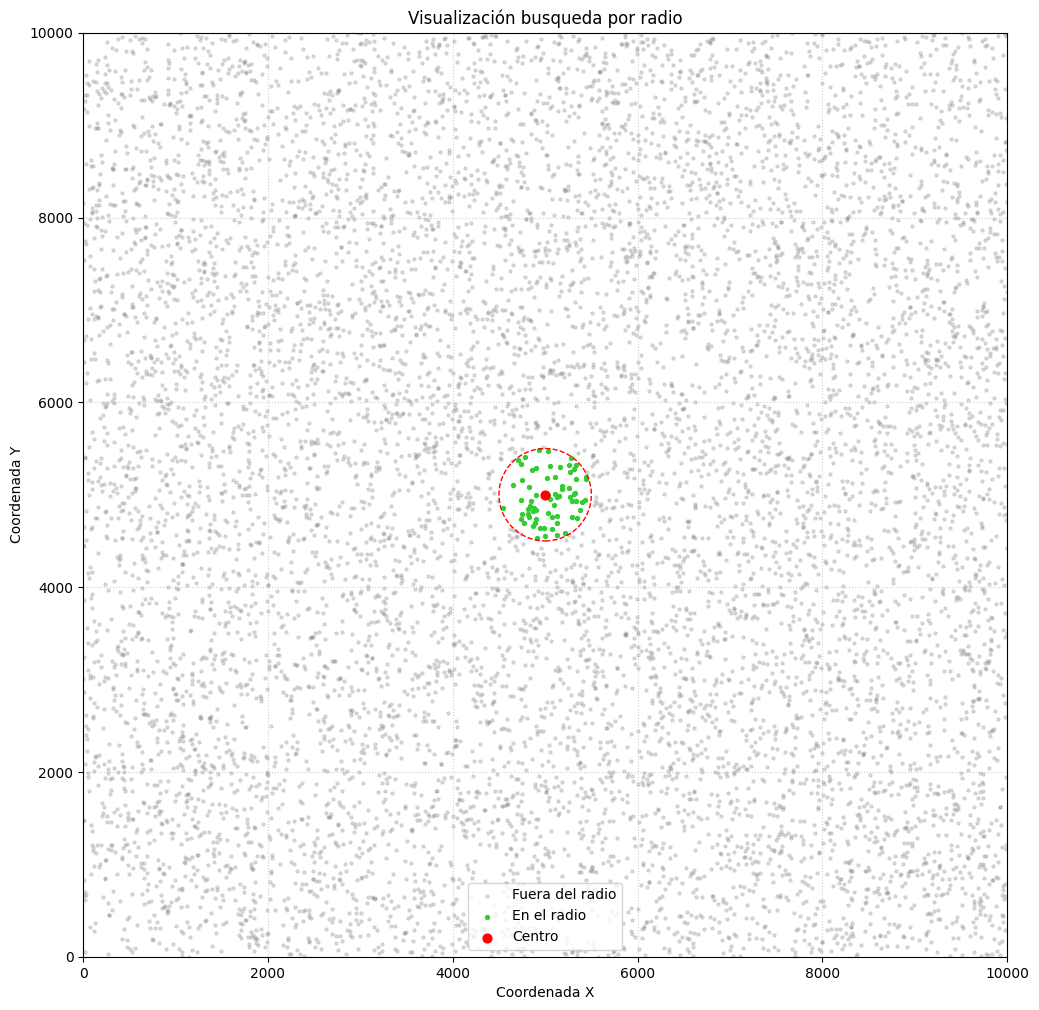

In [51]:
import matplotlib.pyplot as plt

# Todos los puntos
coords_todos = [p["coordenadas"] for p in puntos]
x_todos, y_todos = zip(*coords_todos)

# Puntos en radio (seguro)
coords_radio = [p["coordenadas"] for p in puntos_encontrados]
if coords_radio:
    x_radio, y_radio = zip(*coords_radio)
else:
    x_radio, y_radio = [], []

plt.figure(figsize=(12, 12))

# Puntos base
plt.scatter(x_todos, y_todos, s=5, color = "gray", alpha=0.25, label='Fuera del radio')
plt.scatter(x_radio, y_radio, s=8, color = "limegreen", label='En el radio')

# Centro y círculo
plt.scatter(*centro_busqueda, s=40, label='Centro', color = "red")
plt.gca().add_patch(
    plt.Circle(centro_busqueda, radio, fill=False, color = "red", linestyle='--')
)

# Visual
plt.xlim(0, 10000)
plt.ylim(0, 10000)
plt.gca().set_aspect('equal')
plt.title("Visualización busqueda por radio")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

#**Gráfica 2 — Zoom al área de búsqueda**

Esta visualización realiza un acercamiento detallado al círculo de influencia, permitiendo inspeccionar con precisión la relación espacial entre el centro y los puntos detectados.

---

**¿Qué estamos observando en este nivel?**

* **Centro de búsqueda (Rojo):** Identificado con un marcador para ubicar el origen exacto de la consulta.

* **Puntos en el radio (Verdes):** Los elementos específicos que el algoritmo ha filtrado como válidos.

* **Vínculos de proximidad (Líneas azules):** Se trazan líneas directas desde el centro hacia los **vecinos más cercanos**. Esta representación facilita la inspección visual de la cercanía.

* **Etiquetas de distancia:** Cada línea incluye el valor numérico de la distancia calculada (en metros), lo que sirve como validación final de que el cálculo matemático coincide con la representación geométrica.
---

**¿Por qué es importante este detalle?**

Mientras que la primera gráfica valida el *rango*, esta segunda gráfica valida el **orden y la magnitud**. Nos permite confirmar que el sistema no solo encuentra puntos dentro de un área, sino que es capaz de medir con exactitud la separación entre ellos y priorizar correctamente cuáles son los vecinos más próximos al objetivo, asegurando que la lógica de selección sea impecable.

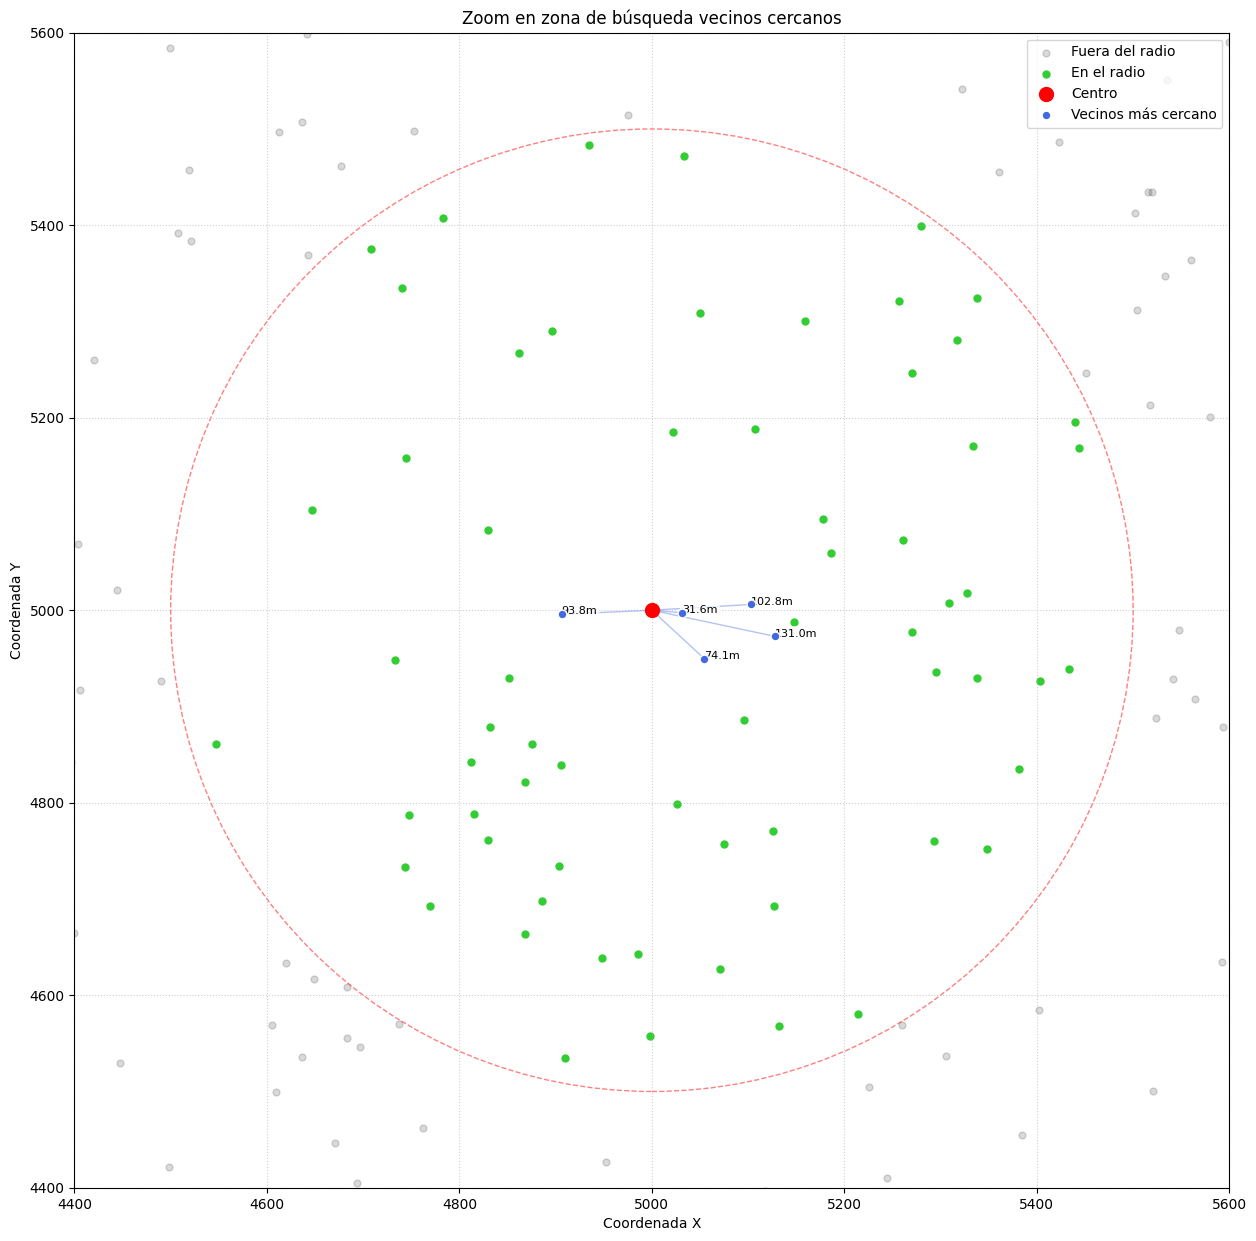

In [52]:
import matplotlib.pyplot as plt

# 1. Filtro para que no haya puntos grises dentro del círculo
ids_excluir = {p["id"] for p in puntos_encontrados}
if 'vecinos' in locals():
    ids_excluir.update({p[1]["id"] for p in vecinos})

# Puntos de fondo (solo los que están fuera de la zona de interés)
coords_fondo = [p["coordenadas"] for p in puntos if p["id"] not in ids_excluir]
x_fondo, y_fondo = zip(*coords_fondo) if coords_fondo else ([], [])

# Puntos en radio
coords_radio = [p["coordenadas"] for p in puntos_encontrados]
x_radio, y_radio = zip(*coords_radio) if coords_radio else ([], [])

plt.figure(figsize=(15, 15))

# Puntos base (fuera)
plt.scatter(x_fondo, y_fondo, s=25, alpha=0.15, color='black', label='Fuera del radio')
# Puntos dentro del radio (verde para diferenciar)
plt.scatter(x_radio, y_radio, s=25, color='limegreen', label='En el radio')

# Centro y círculo
plt.scatter(*centro_busqueda, s=100, color='red', marker='o', label='Centro', zorder=5)
plt.gca().add_patch(
    plt.Circle(centro_busqueda, radio, fill=False, linestyle='--', color='red', alpha=0.5)
)

# DISTANCIAS Y LÍNEAS
if 'vecinos' in locals():
    for i, (dist, p_dict) in enumerate(vecinos):
        cx, cy = centro_busqueda
        px, py = p_dict["coordenadas"]

        # Dibujar línea al vecino
        plt.plot([cx, px], [cy, py], color='royalblue', linewidth=1, alpha=0.4)

        # Etiqueta de distancia
        plt.text(px, py, f"{dist:.1f}m", fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

        # Resaltar el punto KNN (solo el primero lleva label para la leyenda)
        plt.scatter(px, py, s=40, color='royalblue', edgecolors='white', zorder=4,
                    label='Vecinos más cercano' if i == 0 else None)


# Calculamos el margen basado en el radio para que el zoom sea automático
margen = radio * 0.2
plt.xlim(centro_busqueda[0] - radio - margen, centro_busqueda[0] + radio + margen)
plt.ylim(centro_busqueda[1] - radio - margen, centro_busqueda[1] + radio + margen)

plt.gca().set_aspect('equal')
plt.title("Zoom en zona de búsqueda vecinos cercanos")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.show()

# **Búsqueda por fuerza bruta**

---

El código implementa dos funciones para realizar búsquedas espaciales sobre un conjunto de puntos utilizando un enfoque de **fuerza bruta**, es decir, evaluando todos los elementos sin estructuras optimizadas. Para cada consulta se calcula la distancia euclidiana con `math.dist()` entre el punto de referencia y cada elemento del conjunto, lo que resulta en una complejidad de **O(n)** por búsqueda.

Las dos funciones cubren los casos más comunes:

- **`buscar_radio_bruta`**: filtra y retorna todos los puntos cuya distancia al centro sea menor o igual al radio indicado.
- **`buscar_knn_bruta`**: calcula todas las distancias, las ordena de menor a mayor y retorna los primeros `k` vecinos más cercanos.

In [80]:
def buscar_radio_bruta(puntos, centro, radio):
    # Simplemente filtra la lista completa
    return [p for p in puntos if math.dist(p["coordenadas"], centro) <= radio]

def buscar_knn_bruta(puntos, centro, k):
    # Calcula todas las distancias, ordena y toma los primeros k
    distancias = []
    for p in puntos:
        d = math.dist(p["coordenadas"], centro)
        distancias.append((d, p))
    distancias.sort(key=lambda x: x[0])
    return distancias[:k]

#Análisis de Rendimiento: Árboles KD vs Fuerza Bruta

---

Se presenta un benchmarking (prueba de rendimiento) diseñado para comparar la eficiencia temporal de dos métodos de búsqueda espacial aplicados a un conjunto masivo de hasta 200,000 puntos bidimensionales, utilizando implementaciones optimizadas y vectorizadas en Python

---

##**¿Cómo funciona el test?**

El código evalúa dos tipos de consultas espaciales mientras incrementa progresivamente el tamaño del conjunto de datos de prueba ($N$):

- Búsqueda en Radio: Encuentra todos los puntos dentro de una distancia $R$ desde unas coordenadas de origen.

- Búsqueda $k$nn: Localiza los $k$ vecinos más cercanos a un punto específico.

Para cada iteración, el script mide el tiempo exacto de ejecución utilizando time.perf_counter(). Al finalizar, proyecta los resultados en gráficas comparativas mediante matplotlib, utilizando una escala logarítmica en el eje Y para visualizar correctamente las enormes diferencias de magnitud en los tiempos.

---
##**Fundamento Teórico y Complejidad**

El objetivo del test es demostrar las siguientes diferencias matemáticas en la complejidad computacional temporal:

- Búsqueda por Fuerza Bruta:
Calcula la distancia entre el punto de origen y absolutamente todos los demás puntos del conjunto. Su tiempo de ejecución crece de forma lineal y directamente proporcional a la cantidad de datos.

- Complejidad de búsqueda: ($O(n)$)

---

##**Búsqueda mediante KD-Tree**

Utiliza una estructura de datos que divide el espacio iterativamente. Al buscar, el algoritmo puede descartar ramas enteras del árbol basándose en límites geométricos sin calcular sus distancias reales, lo que reduce drásticamente las operaciones necesarias.

- Complejidad de búsqueda (caso promedio):$$O(\log N)$$

- Complejidad de construcción del árbol:$$O(N \log N)$$

---

##**Resultados**

Al observar los gráficos generados (configurados con escala logarítmica para los tiempos), se evidencia una divergencia dramática entre ambos métodos. La línea de Fuerza Bruta mostrará un crecimiento marcado a medida que los puntos aumentan, acercándose a los 0.01 segundos.

En contraste, la línea del KD-Tree permanecerá casi plana en la parte inferior del gráfico (en el orden de los 0.0001 segundos). Esta separación de múltiples órdenes de magnitud demuestra que, para grandes volúmenes de datos espaciales, la complejidad logarítmica del árbol supera abrumadoramente incluso a la fuerza bruta más optimizada.


Ejecutando pruebas optimizadas...


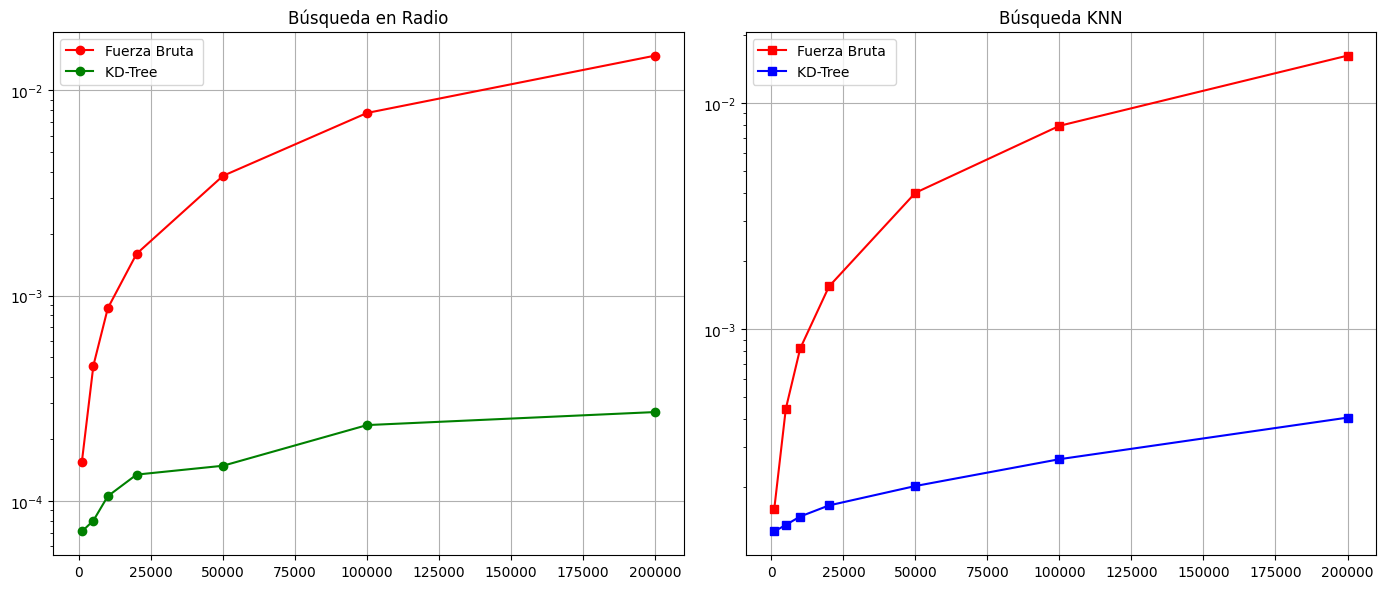

In [81]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# Configuramos la semilla
np.random.seed(42)
LIMITES = [0, 10000]

def generar_puntos_opt(cantidad):
    """Genera una matriz NumPy de (cantidad, 2) mucho más rápido."""
    return np.random.uniform(LIMITES[0], LIMITES[1], size=(cantidad, 2))

# definimos los tamaños de datos y fijamos los valores que estaran fijos solo tocamos los tamaños de los datos
def ejecutar_test_grafico_opt():
    tamaños_datos = [1000, 5000, 10000, 20000, 50000, 100000, 200000] # Aumentamos N
    radio_busqueda = 500
    k_vecinos = 5

    tiempos_radio_bruta = []
    tiempos_radio_kd = []
    tiempos_knn_bruta = []
    tiempos_knn_kd = []

    print("Ejecutando pruebas optimizadas...")

    for n in tamaños_datos:
        puntos = generar_puntos_opt(n)
        # Construcción del árbol (Scipy lo hace en milisegundos)
        tree = KDTree(puntos)

        centro_prueba = np.random.uniform(LIMITES[0], LIMITES[1], size=(1, 2))

        # --- prueba 1: RADIO ---
        # Bruta (usando vectorización de NumPy para que sea una competencia justa)
        inicio = time.perf_counter()
        distancias = np.linalg.norm(puntos - centro_prueba, axis=1)
        _ = puntos[distancias <= radio_busqueda]
        tiempos_radio_bruta.append(time.perf_counter() - inicio)

        # KD-Tree
        inicio = time.perf_counter()
        _ = tree.query_ball_point(centro_prueba[0], radio_busqueda)
        tiempos_radio_kd.append(time.perf_counter() - inicio)

        # --- prueba 2: KNN busqueda ---
        # Bruta
        inicio = time.perf_counter()
        distancias = np.linalg.norm(puntos - centro_prueba, axis=1)
        _ = np.argpartition(distancias, k_vecinos)[:k_vecinos]
        tiempos_knn_bruta.append(time.perf_counter() - inicio)

        # KD-Tree
        inicio = time.perf_counter()
        _ = tree.query(centro_prueba[0], k=k_vecinos)
        tiempos_knn_kd.append(time.perf_counter() - inicio)

    # --- GRÁFICAS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.plot(tamaños_datos, tiempos_radio_bruta, 'r-o', label='Fuerza Bruta ')
    ax1.plot(tamaños_datos, tiempos_radio_kd, 'g-o', label='KD-Tree ')
    ax1.set_title('Búsqueda en Radio')
    ax1.set_yscale('log') # Escala logarítmica para ver la diferencia real
    ax1.legend(); ax1.grid(True)

    ax2.plot(tamaños_datos, tiempos_knn_bruta, 'r-s', label='Fuerza Bruta ')
    ax2.plot(tamaños_datos, tiempos_knn_kd, 'b-s', label='KD-Tree ')
    ax2.set_title('Búsqueda KNN')
    ax2.set_yscale('log')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    ejecutar_test_grafico_opt()

#Análisis de Rendimiento: El Punto de Cruce entre Árboles KD y Fuerza Bruta

---

presenta una prueba diseñada para identificar el umbral exacto (punto de cruce algorítmico) donde la complejidad estructural de un KD-Tree comienza a ofrecer ventajas temporales reales sobre una búsqueda lineal por Fuerza Bruta en conjuntos de datos pequeños.

---

##**¿Cómo funciona el test?**

A diferencia de las pruebas a gran escala, este script hace un zoom analítico a cantidades de puntos muy reducidas. Evalúa las búsquedas incrementando el tamaño del conjunto de datos ($N$) en intervalos cortos de 10 unidades, partiendo desde 10 hasta llegar a 1,000.

Dado que a estas escalas las operaciones duran apenas fracciones de milisegundo, el código implementa una estrategia estricta para garantizar la precisión:

- Se ejecuta la misma búsqueda 200 veces por cada incremento de $N$.

- Se acumulan los tiempos y se dividen para obtener un promedio limpio, eliminando el ruido natural del sistema operativo y las fluctuaciones del procesador.

- Los resultados se transforman internamente a milisegundos para proyectar una visualización gráfica clara y legible.

---

##**Fundamento Teórico: Sobrecarga vs Complejidad**

El objetivo del test es demostrar que el mejor algoritmo teórico no siempre es el más rápido en la práctica para conjuntos de datos diminutos, debido a un fenómeno conocido como sobrecarga:

- Fuerza Bruta (Baja sobrecarga, Complejidad $O(N)$): Es un algoritmo computacionalmente simple. No requiere preparar estructuras ni realizar llamadas recursivas; solo ejecuta un bucle directo. Por su simplicidad mecánica, el procesador lo resuelve casi instantáneamente cuando hay pocos datos, a pesar de que su costo total escale de manera lineal

- KD-Tree (Alta sobrecarga, Complejidad $O(\log N)$):
Es un algoritmo inteligente que descarta zonas espaciales para evitar cálculos innecesarios. Sin embargo, esta lógica tiene un costo operativo intrínseco (evaluar límites geométricos, navegar por los nodos del árbol, gestionar la memoria de las listas). Para valores de $N$ muy pequeños, el tiempo invertido en "navegar" la estructura del árbol supera el tiempo que tomaría simplemente revisar todos los puntos secuencialmente.

---

##**Análisis de Resultados y el Punto de Inflexión**

Al observar la gráfica generada, la teoría algorítmica se confirma visualmente en tres fases claramente delimitadas:

- La ventaja inicial de la Fuerza Bruta: En el extremo izquierdo de la gráfica (para $N < 100$), la curva de la Fuerza Bruta se mantiene por debajo de la del KD-Tree. A esta escala microscópica, la simplicidad pura le gana a la estructura compleja.

- El Punto de Cruce: Alrededor de los 100 puntos, ambas líneas colisionan e invierten posiciones. Este es el umbral matemático exacto donde la "inteligencia" del KD-Tree logra amortizar su costo inicial de navegación.

- Pasado el punto de cruce, la Fuerza Bruta expone su ineficiencia a escala y comienza una inevitable trayectoria ascendente (crecimiento lineal). En paralelo, el KD-Tree estabiliza su tiempo de ejecución, formando una línea de crecimiento logarítmico casi horizontal que demuestra su dominio absoluto para cualquier cantidad de datos superior a este umbral.

Buscando el punto de cruce para N pequeños... (Esto puede tomar unos segundos)


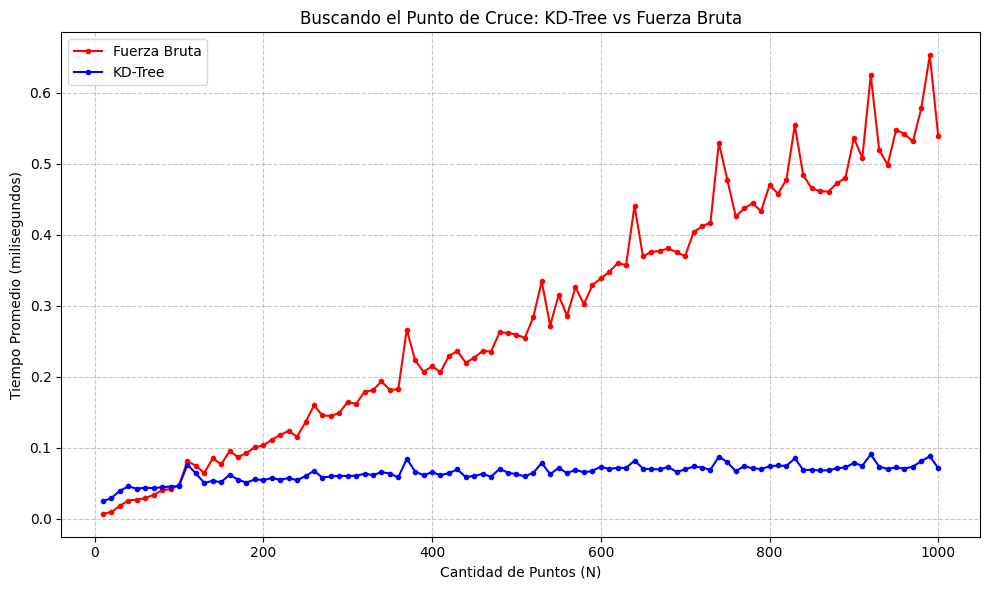

In [60]:
import time
import random
import matplotlib.pyplot as plt

def test_punto_de_cruce():
    # Evaluamos tamaños de datos pequeños, empezando en 10 y saltando de 10 en 10 hasta 1000
    tamanos_datos = list(range(10, 1001, 10))
    intentos_por_n = 200 # Alto número de promedios porque los tiempos serán casi cero
    k_vecinos = 5

    tiempos_bruta = []
    tiempos_kd = []

    print("Buscando el punto de cruce para N pequeños... (Esto puede tomar unos segundos)")

    for n in tamanos_datos:
        puntos = generar_puntos(n)
        raiz = construccion_arbolKD(puntos)

        t_bruta_total = 0
        t_kd_total = 0

        for _ in range(intentos_por_n):
            centro_prueba = [
                round(random.uniform(LON_MIN, LON_MAX), 6),
                round(random.uniform(LAT_MIN, LAT_MAX), 6)
            ]

            # Busqueda Fuerza Bruta
            inicio = time.perf_counter()
            # Usamos min() por si N es menor que los 5 vecinos que buscamos
            buscar_knn_bruta(puntos, centro_prueba, k=min(k_vecinos, n))
            t_bruta_total += (time.perf_counter() - inicio)

            # Busqueda KD-Tree
            inicio = time.perf_counter()
            buscar_knn(raiz, centro_prueba, k=min(k_vecinos, n), cercanos=[])
            t_kd_total += (time.perf_counter() - inicio)

        # Convertimos los resultados a MILISEGUNDOS para verlos mejor en la gráfica
        tiempos_bruta.append((t_bruta_total / intentos_por_n) * 1000)
        tiempos_kd.append((t_kd_total / intentos_por_n) * 1000)

    # --- CREACIÓN DE LA GRÁFICA ---
    plt.figure(figsize=(10, 6))

    plt.plot(tamanos_datos, tiempos_bruta, marker='.', color='red', label='Fuerza Bruta')
    plt.plot(tamanos_datos, tiempos_kd, marker='.', color='blue', label='KD-Tree')

    plt.title('Buscando el Punto de Cruce: KD-Tree vs Fuerza Bruta')
    plt.xlabel('Cantidad de Puntos (N)')
    plt.ylabel('Tiempo Promedio (milisegundos)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Ejecutar el test
test_punto_de_cruce()

#**Conclusiones del Análisis Comparativo: KD-Tree vs. Fuerza Bruta**

Basándonos en las gráficas obtenidas y en el comportamiento de los algoritmos bajo diferentes volúmenes de datos, tenemos las siguientes conclusiones:

---

##**¿Para qué tamaño de datos el KD-Tree comienza a ser más rápido que la Fuerza Bruta?**

Observando la gráfica específica del Punto de Cruce (la prueba para $N$ pequeños), el umbral exacto donde el árbol KD comienza a ser superior ocurre alrededor de los 100 puntos ($N \approx 100$).

- Para $N < 100$: La búsqueda lineal clásica (Fuerza Bruta) en arreglos o listas es consistentemente más rápida.

- Para $N > 100$: El KD-Tree toma la delantera y, a partir de ese momento, la brecha de rendimiento a su favor no deja de crecer exponencialmente, como se evidencia en las gráficas de hasta 200,000 puntos.

---

##**¿Que aprendemos con estos resultados?**

Este experimento nos deja tres grandes lecciones prácticas y teóricas sobre las ciencias de la computación:

**El impacto de la Sobrecarga**

- las estructuras de datos complejas no son gratuitas. Tienen un costo inicial de preparación, asignación de memoria y navegación de nodos. Para volúmenes de datos minúsculos, el tiempo que el procesador invierte en ejecutar la estructura del árbol es mayor que el tiempo que le tomaría simplemente leer los datos de forma plana y directa. La simplicidad gana a pequeña escala.

**La teoría de la Complejidad es real y observable**

- Las gráficas demuestran perfectamente cómo se comportan las matemáticas en el hardware real. Aprendemos que un algoritmo con complejidad lineal $O(N)$ de Fuerza Bruta está condenado a colapsar a medida que los datos crecen, haciendo que el tiempo se dispare haciendolo ineficiente y engorroso. Por el contrario, un algoritmo con complejidad logarítmica $O(\log N)$ como el KD-Tree absorbe el impacto del crecimiento masivo de datos manteniendo tiempos de respuesta casi horizontales y estables aun con volumenes de datos inmensos.

**No existe un algoritmo perfecto para todo**

- Para el desarrollo de software el contexto define a la herramienta su proposito. en este caso un sistema que compare la ubicacion de diferente puntos para una empresa de logistica que maneje solo 10 o 40 puntos es una perdida de tiempo y recursos usar la implementacion de KD-Tree aunque si se escala a puntos de hasta 500.000 puntos de coordenadas o en este caso del ejercicio que fueron 10.000 es de ley usar el arbol-KD tener una lista simple de fuerza bruta hara que el sistema sea inoperable y no funcional.




